In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de fonte Arial e Estilo
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

def aplicar_estilo_esalq(ax):
    """Padroniza eixos, remove grid e define espessura 1.5pt."""
    ax.grid(False)
    ax.set_facecolor('none')
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title("") # Títulos serão manuais ou inferiores

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Caminho para o CSV bruto
path_2023 = r"C:\Users\Claudia\Documents\TCC\data\raw\2023\DADOS\MICRODADOS_ENEM_2023.csv"

# O SEGREDO PARA A MEMÓRIA: Carregar apenas as colunas que vamos usar
colunas_necessarias = ['TP_SEXO', 'NU_NOTA_MT']

df23 = pd.read_csv(path_2023, 
                   encoding='latin1', 
                   sep=";", 
                   on_bad_lines='skip', 
                   usecols=colunas_necessarias)

# Criando as séries de dados sem duplicar o dataframe
# Removemos nulos e notas zero (que podem distorcer a análise de desempenho)
notas_mt_F23 = df23[df23['TP_SEXO'] == 'F']['NU_NOTA_MT'].dropna()
notas_mt_F23 = notas_mt_F23[notas_mt_F23 > 0]

notas_mt_M23 = df23[df23['TP_SEXO'] == 'M']['NU_NOTA_MT'].dropna()
notas_mt_M23 = notas_mt_M23[notas_mt_M23 > 0]

notas_mt_Geral23 = df23['NU_NOTA_MT'].dropna()
notas_mt_Geral23 = notas_mt_Geral23[notas_mt_Geral23 > 0]

# Lista para a função
dados_para_plot = [notas_mt_Geral23, notas_mt_F23, notas_mt_M23]

# Liberar memória do dataframe original após extrair as séries
del df23

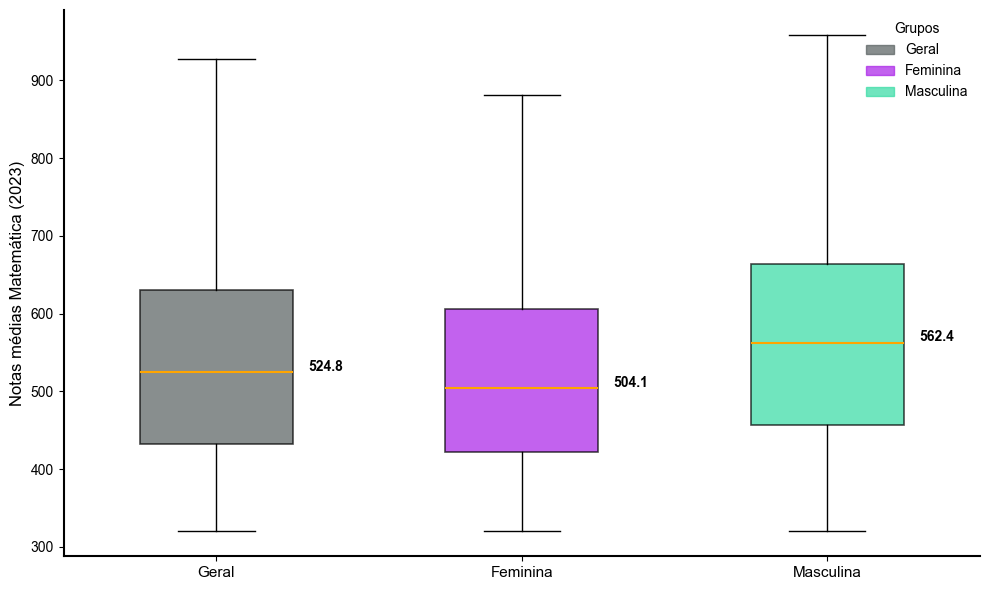

In [27]:
# Cores do seu projeto
CORES_GMF = ["#565E5F", "#A81FE7", "#34dba3"] # Geral, Feminino, Masculino

def plotar_boxplot_final(lista_dados):
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Gerando o boxplot
    # showfliers=False remove os outliers conforme solicitado
    bp = ax.boxplot(lista_dados, patch_artist=True, showfliers=False, widths=0.5)
    
    # Aplicando as cores e estilo das caixas
    for patch, color in zip(bp['boxes'], CORES_GMF):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_linewidth(1.2)
        patch.set_edgecolor('black')

    # Estilizando as linhas (medianas, bigodes, etc)
    plt.setp(bp['medians'], color='orange', linewidth=1.5)
    
    # Inserindo os números das medianas acima das linhas
    for i, line in enumerate(bp['medians']):
        x, y = line.get_xydata()[1] 
        ax.text(x + 0.05, y + 2, f'{y:.1f}', fontweight='bold', color='black', fontsize=10)

    # REGRAS DE OURO DA ESTÉTICA SOLICITADA:
    ax.grid(False) # Sem grid
    ax.set_facecolor('none') # Sem fundo
    ax.set_title("") # Sem título
    
    # Eixos com 1.5pt
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Legenda e rótulos
    labels = ['Geral', 'Feminina', 'Masculina']
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel('Notas médias Matemática (2023)', fontsize=12)
    
    # Legenda manual centralizada
    legend_patches = [mpatches.Patch(color=CORES_GMF[i], label=labels[i], alpha=0.7) for i in range(len(labels))]
    ax.legend(handles=legend_patches, title="Grupos", frameon=False, prop={'family': 'Arial'})

    plt.tight_layout()
    plt.show()

# Chamada da função
plotar_boxplot_final(dados_para_plot)

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Configuração global de fonte e estilo
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

# Função auxiliar para limpar eixos
def format_pizza_axis(ax):
    """Remove eixos e caixas para um visual de pizza limpo."""
    ax.axis('off')
    ax.set_facecolor('none')

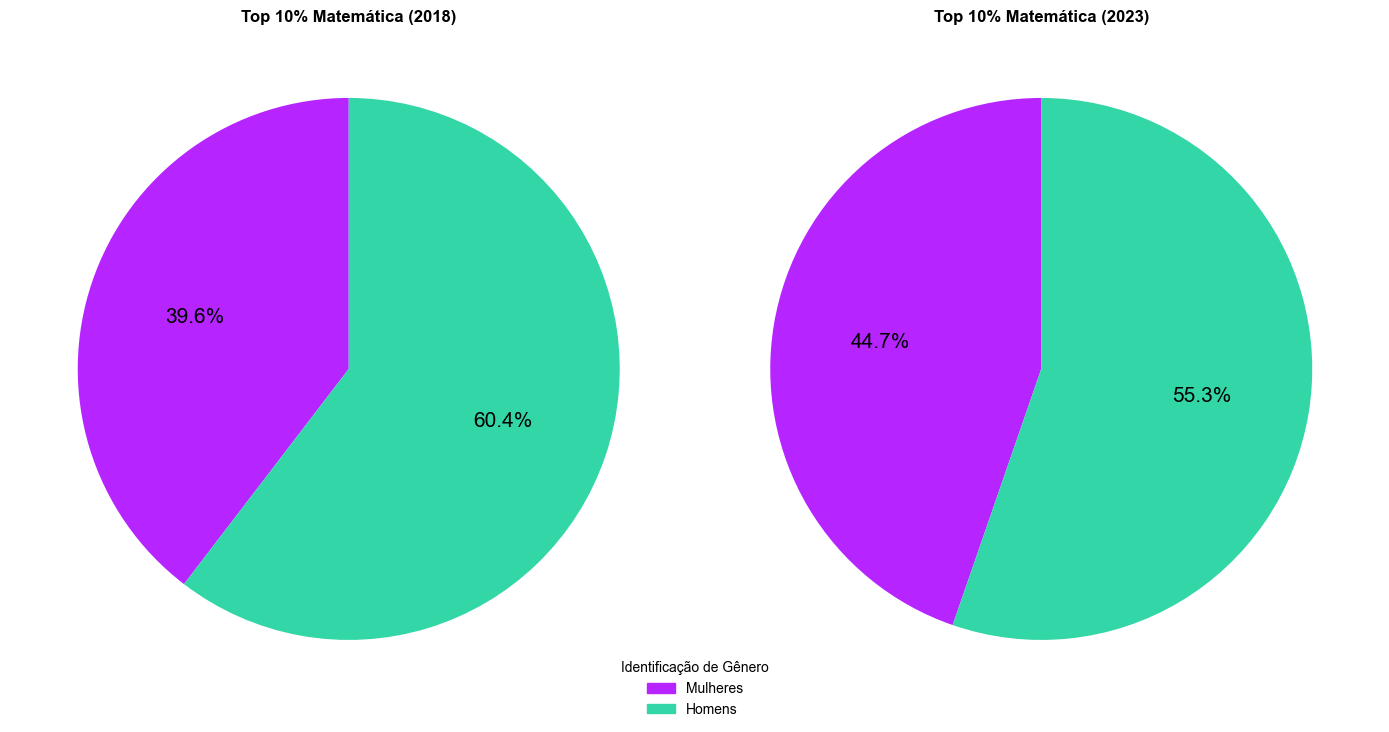

In [35]:
# Dados das porcentagens exatas para Matemática
pie_data_math = {
    '2018': {'Mulheres': 39.6, 'Homens': 60.4},
    '2023': {'Mulheres': 44.7, 'Homens': 55.3}
}

colors = ['#B624FF', '#33D6A6']
labels = ['Mulheres', 'Homens']

# Criação da figura com dois subplots lado a lado
fig, axs = plt.subplots(1, 2, figsize=(14, 8))

# Loop para gerar os dois gráficos
for i, year in enumerate(['2018', '2023']):
    ax = axs[i]
    valores = [pie_data_math[year]['Mulheres'], pie_data_math[year]['Homens']]
    
    # Gráfico de pizza com bordas lisas (nenhuma borda)
    wedges, texts, autotexts = ax.pie(
        valores, labels=None, autopct='%1.1f%%', startangle=90, 
        colors=colors, wedgeprops={'edgecolor': 'none'},
        textprops={'fontfamily': 'Arial', 'fontsize': 15}
    )
    
    # Formatação das porcentagens
    for t in autotexts:
        t.set_fontfamily('Arial')
    
    # Título acima de cada pizza
    ax.set_title(f"Top 10% Matemática ({year})", fontfamily='Arial', fontsize=12, fontweight='bold')
    
    # Ajuste para visualização limpa
    format_pizza_axis(ax)

# Criação da legenda centralizada na base para a figura inteira
legend_patches = [mpatches.Patch(color=colors[0], label=labels[0]),
                  mpatches.Patch(color=colors[1], label=labels[1])]

# Adiciona legenda comum centralizada na base
# bbox_to_anchor ajustado para ficar na faixa inferior sem esbarrar
fig.legend(handles=legend_patches, title="Identificação de Gênero", 
           loc='lower center', bbox_to_anchor=(0.5, 0.05), 
           frameon=False, prop={'family': 'Arial'})

# Ajuste fino de espaçamento para legenda na base
fig.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.show()

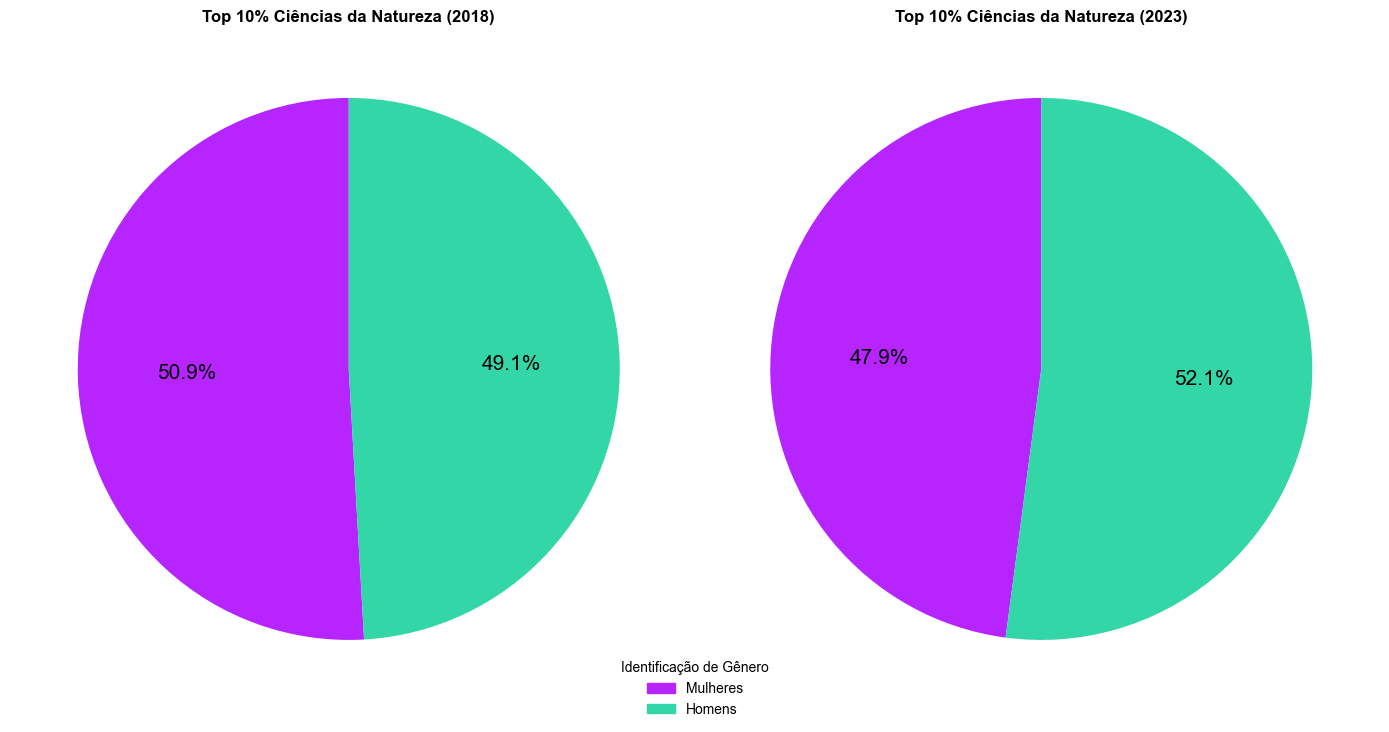

In [ ]:


# Dados das porcentagens exatas para Ciências da Natureza
pie_data_cn = {
    '2018': {'Mulheres': 50.9, 'Homens': 49.1},
    '2023': {'Mulheres': 47.9, 'Homens': 52.1}
}

# Criação da figura com dois subplots lado a lado
fig, axs = plt.subplots(1, 2, figsize=(14, 8))

# Loop para gerar os dois gráficos
for i, year in enumerate(['2018', '2023']):
    ax = axs[i]
    valores = [pie_data_cn[year]['Mulheres'], pie_data_cn[year]['Homens']]
    
    # Gráfico de pizza com bordas lisas (nenhuma borda)
    wedges, texts, autotexts = ax.pie(
        valores, labels=None, autopct='%1.1f%%', startangle=90, 
        colors=colors, wedgeprops={'edgecolor': 'none'},
        textprops={'fontfamily': 'Arial', 'fontsize': 15}
    )
    
    # Formatação das porcentagens
    for t in autotexts:
        t.set_fontfamily('Arial')
    
    # Título acima de cada pizza
    ax.set_title(f"Top 10% Ciências da Natureza ({year})", fontfamily='Arial', fontsize=12, fontweight='bold')
    
    # Ajuste para visualização limpa
    format_pizza_axis(ax)

# Reutilizando legend_patches definidos acima

# Adiciona legenda comum centralizada na base
fig.legend(handles=legend_patches, title="Identificação de Gênero", 
           loc='lower center', bbox_to_anchor=(0.5, 0.05), 
           frameon=False, prop={'family': 'Arial'})

# Ajuste fino de espaçamento para legenda na base
fig.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.show()

In [24]:
path_2023 = r"C:\Users\Claudia\Documents\TCC\data\raw\2023\DADOS\MICRODADOS_ENEM_2023.csv"
df_2023 = pd.read_csv(path_2023, encoding='latin1', sep=";", on_bad_lines='skip')

# Preparando os dados: Matemática
df_m = df_2023[['TP_SEXO', 'NU_NOTA_MT']].copy()
df_m['Grupo'] = df_m['TP_SEXO'].map({'F': 'Feminina', 'M': 'Masculina'})

# Criando o DF para o gráfico incluindo o "Geral"
df_geral = df_m.copy()
df_geral['Grupo'] = 'Geral'
df_boxplot = pd.concat([df_geral, df_m])

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_boxplot, x='Grupo', y='NU_NOTA_MT', 
    palette=['gray', '#C77CFF', '#7CAE96'], 
    ax=ax, width=0.5, showfliers=False, order=['Geral', 'Feminina', 'Masculina']
)

# Cálculo e exibição das medianas reais do seu dataset
medians = df_boxplot.groupby('Grupo')['NU_NOTA_MT'].median().reindex(['Geral', 'Feminina', 'Masculina'])
for i, median in enumerate(medians):
    ax.text(i + 0.32, median + 2, f'{median:.1f}', fontweight='bold', color='black')

format_thesis_plot(ax)
ax.set_title("")
ax.set_ylabel("Notas")
ax.set_xlabel("")

plt.tight_layout()
plt.show()

MemoryError: Unable to allocate 630. MiB for an array with shape (21, 3933955) and data type float64

Lendo arquivo de 2018 em blocos...
Processando melt para 2018...


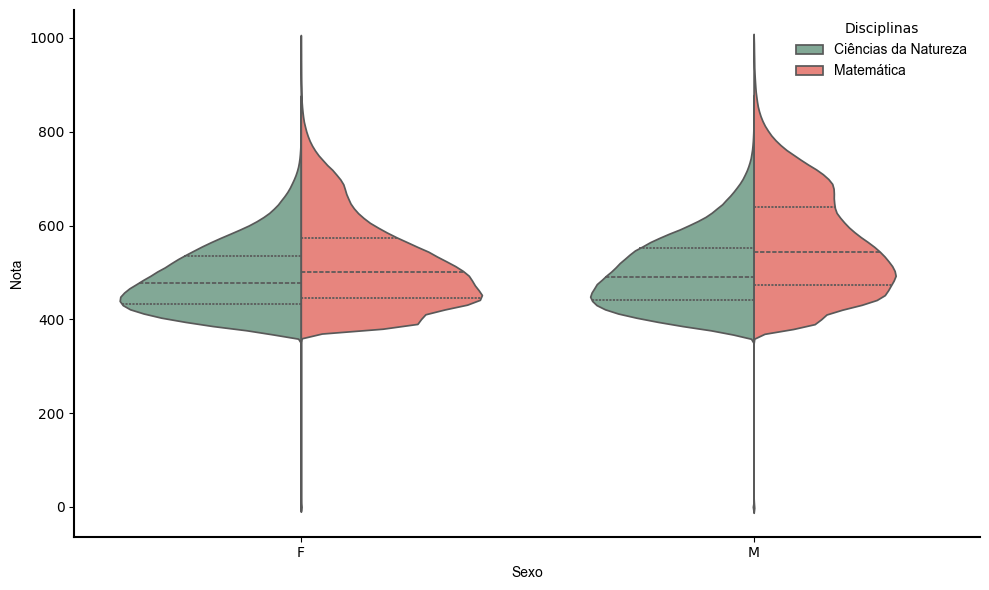

Lendo arquivo de 2023 em blocos...
Processando melt para 2023...


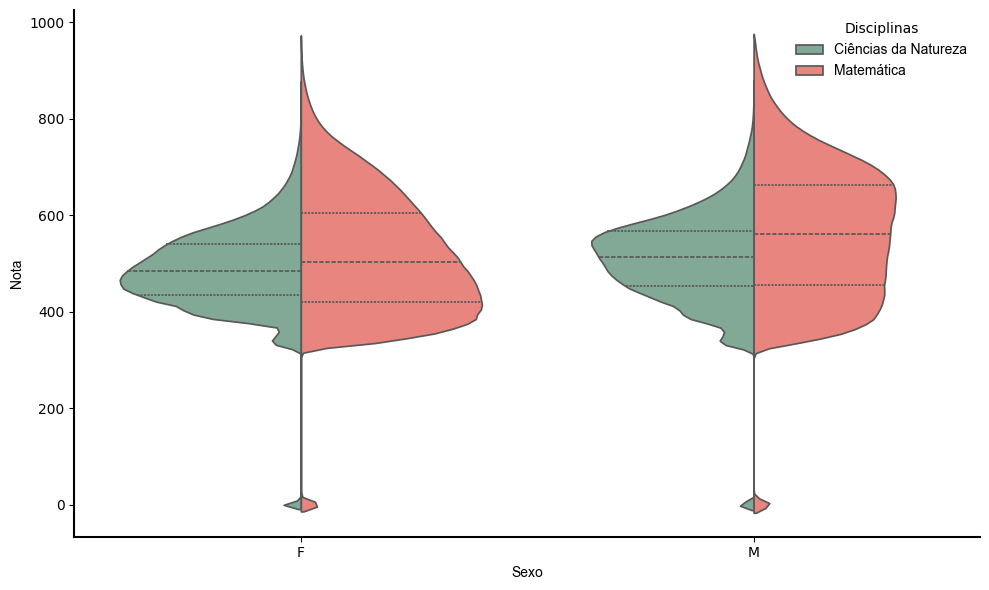

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def aplicar_estilo_esalq(ax):
    ax.grid(False)
    ax.set_facecolor('none')
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def plot_violin_year_low_mem(path, year_label):
    colunas = ['TP_SEXO', 'NU_NOTA_CN', 'NU_NOTA_MT']
    
    # Definimos tipos de dados menores (float32 em vez de float64) para economizar 50% de RAM
    tipos = {'TP_SEXO': 'category', 'NU_NOTA_CN': 'float32', 'NU_NOTA_MT': 'float32'}
    
    chunks = []
    
    # Lendo o arquivo em pedaços de 500 mil linhas por vez
    print(f"Lendo arquivo de {year_label} em blocos...")
    reader = pd.read_csv(path, 
                         encoding='latin1', 
                         sep=";", 
                         on_bad_lines='skip', 
                         usecols=colunas,
                         dtype=tipos,
                         chunksize=500000)
    
    for chunk in reader:
        # Limpa o bloco atual antes de guardar
        chunk = chunk.dropna(subset=['NU_NOTA_CN', 'NU_NOTA_MT'], how='all')
        chunks.append(chunk)
    
    # Consolida os blocos limpos
    df = pd.concat(chunks, ignore_index=True)
    del chunks # Limpa a lista da memória
    
    print(f"Processando melt para {year_label}...")
    df_melt = df.melt(id_vars=['TP_SEXO'], 
                      value_vars=['NU_NOTA_CN', 'NU_NOTA_MT'],
                      var_name='Disciplina', 
                      value_name='Nota')
    
    del df # Deleta o dataframe original imediatamente
    
    df_melt['Disciplina'] = df_melt['Disciplina'].map({
        'NU_NOTA_CN': 'Ciências da Natureza', 
        'NU_NOTA_MT': 'Matemática'
    })

    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.violinplot(
        data=df_melt, 
        x='TP_SEXO', 
        y='Nota', 
        hue='Disciplina', 
        split=True, 
        inner="quart", 
        palette={'Ciências da Natureza': '#7CAE96', 'Matemática': '#F8766D'}, 
        ax=ax
    )
    
    ax.set_xlabel("Sexo", fontfamily='Arial')
    ax.set_ylabel("Nota", fontfamily='Arial')
    ax.legend(title="Disciplinas", prop={'family': 'Arial'}, frameon=False)
    
    aplicar_estilo_esalq(ax)
    
    plt.tight_layout()
    plt.show()
    
    del df_melt # Limpeza final

# Chamadas
plot_violin_year_low_mem(r"C:\Users\Claudia\Documents\TCC\data\raw\2018\dados\MICRODADOS_ENEM_2018.csv", "2018")
plot_violin_year_low_mem(r"C:\Users\Claudia\Documents\TCC\data\raw\2023\DADOS\MICRODADOS_ENEM_2023.csv", "2023")

In [ ]:
def aplicar_estilo_esalq(ax):
    """Padroniza eixos, remove grid e define espessura 1.5pt."""
    ax.grid(False)
    ax.set_facecolor('none')
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title("") # Títulos serão manuais ou inferiores

def plot_violin_year(path, year_label):
    df = pd.read_csv(path, encoding='latin1', sep=";", on_bad_lines='skip')
    
    # "Derretendo" o dataframe para ter a coluna Disciplina (necessário para o hue)
    df_melt = df.melt(id_vars=['TP_SEXO'], value_vars=['NU_NOTA_CN', 'NU_NOTA_MT'],
                      var_name='Disciplina', value_name='Nota')
    df_melt['Disciplina'] = df_melt['Disciplina'].map({'NU_NOTA_CN': 'Ciências da Natureza', 'NU_NOTA_MT': 'Matemática'})
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.violinplot(
        data=df_melt, x='TP_SEXO', y='Nota', hue='Disciplina', 
        split=True, inner="quart", 
        palette={'Ciências da Natureza': '#7CAE96', 'Matemática': '#F8766D'}, ax=ax
    )
    
    ax.set_title("")
    ax.set_xlabel("Sexo")
    ax.set_ylabel("Nota")
    ax.legend(title="Disciplinas", prop={'family': 'Arial'}, frameon=False)
    aplicar_estilo_esalq(ax)
    
    print(f"Gráfico Violin — {year_label}")
    plt.show()

# Gerando os dois gráficos
plot_violin_year(r"C:\Users\Claudia\Documents\TCC\data\raw\2018\dados\MICRODADOS_ENEM_2018.csv", "2018")
plot_violin_year(r"C:\Users\Claudia\Documents\TCC\data\raw\2023\DADOS\MICRODADOS_ENEM_2023.csv", "2023")

MemoryError: Unable to allocate 1.07 GiB for an array with shape (26, 5513733) and data type float64

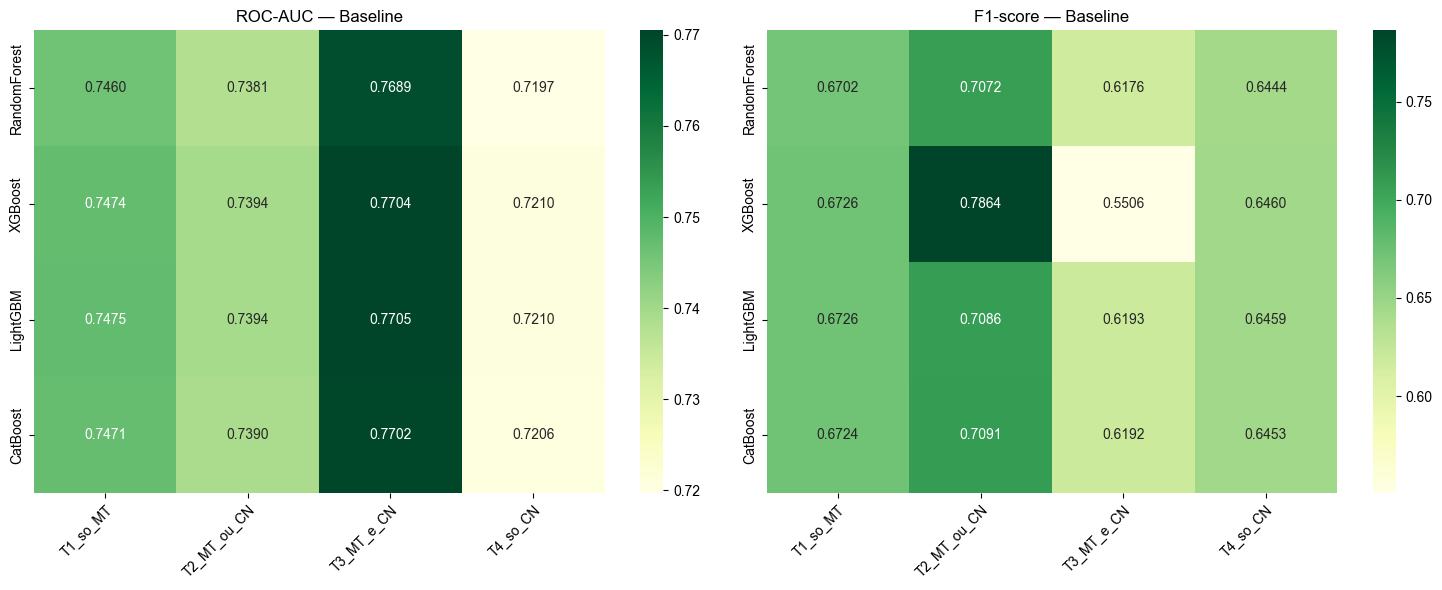

In [8]:
# 1. Definindo as categorias
index = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
columns = ['T1_so_MT', 'T2_MT_ou_CN', 'T3_MT_e_CN', 'T4_so_CN']

# 2. Criando o DataFrame de ROC-AUC com os valores exatos
data_roc = np.array([
    [0.7460, 0.7381, 0.7689, 0.7197],
    [0.7474, 0.7394, 0.7704, 0.7210],
    [0.7475, 0.7394, 0.7705, 0.7210],
    [0.7471, 0.7390, 0.7702, 0.7206]
])
df_metrics_roc_direct = pd.DataFrame(data_roc, index=index, columns=columns)

# 3. Criando o DataFrame de F1-score com os valores exatos
data_f1 = np.array([
    [0.6702, 0.7072, 0.6176, 0.6444],
    [0.6726, 0.7864, 0.5506, 0.6460],
    [0.6726, 0.7086, 0.6193, 0.6459],
    [0.6724, 0.7091, 0.6192, 0.6453]
])
df_metrics_f1_direct = pd.DataFrame(data_f1, index=index, columns=columns)

# 4. Gerando a figura com dois painéis
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap de ROC-AUC
sns.heatmap(df_metrics_roc_direct, annot=True, fmt=".4f", cmap="YlGn", ax=axs[0], cbar=True, annot_kws={'family': 'Arial'})
axs[0].set_title("ROC-AUC — Baseline", fontfamily='Arial')
axs[0].grid(False)

# Heatmap de F1-score
sns.heatmap(df_metrics_f1_direct, annot=True, fmt=".4f", cmap="YlGn", ax=axs[1], cbar=True, annot_kws={'family': 'Arial'})
axs[1].set_title("F1-score — Baseline", fontfamily='Arial')
axs[1].grid(False)

# Rotacionando os rótulos do eixo x para melhor leitura
for ax in axs:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

plt.tight_layout()
plt.show()

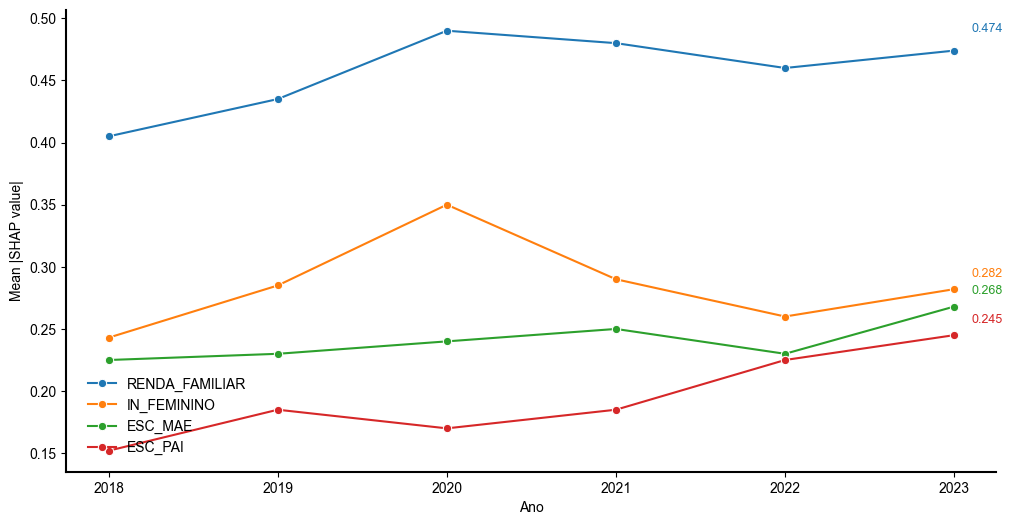

In [9]:
# 1. Definindo os pontos exatos e anos
years = [2018, 2019, 2020, 2021, 2022, 2023]
# Os valores intermediários foram estimados para replicar a curva
data_shap = {
    'Ano': years,
    'RENDA_FAMILIAR': [0.405, 0.435, 0.490, 0.480, 0.460, 0.474], 
    'IN_FEMININO': [0.243, 0.285, 0.350, 0.290, 0.260, 0.282], 
    'ESC_MAE': [0.225, 0.230, 0.240, 0.250, 0.230, 0.268], 
    'ESC_PAI': [0.152, 0.185, 0.170, 0.185, 0.225, 0.245] 
}
df_shap_direct = pd.DataFrame(data_shap)

# 2. Gerando o gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Plotando cada variável
for coluna in ['RENDA_FAMILIAR', 'IN_FEMININO', 'ESC_MAE', 'ESC_PAI']:
    sns.lineplot(data=df_shap_direct, x='Ano', y=coluna, marker='o', ax=ax, label=coluna)
    
    # Adicionando o valor final na ponta (os valores textuais da sua imagem)
    final_val = df_shap_direct[coluna].iloc[-1]
    # Ajuste de posição para não sobrepor
    y_offset = 0.015 if coluna == 'RENDA_FAMILIAR' else 0.01
    ax.text(2023.1, final_val + y_offset, f'{final_val:.3f}', fontsize=9, fontfamily='Arial', color=ax.lines[-1].get_color())

# Aplicando formatação limpa
format_spines_clean(ax)
ax.set_ylabel("Mean |SHAP value|")
ax.legend(prop={'family': 'Arial'}, frameon=False, bbox_to_anchor=(0.01, 0.01), loc='lower left')
plt.show()

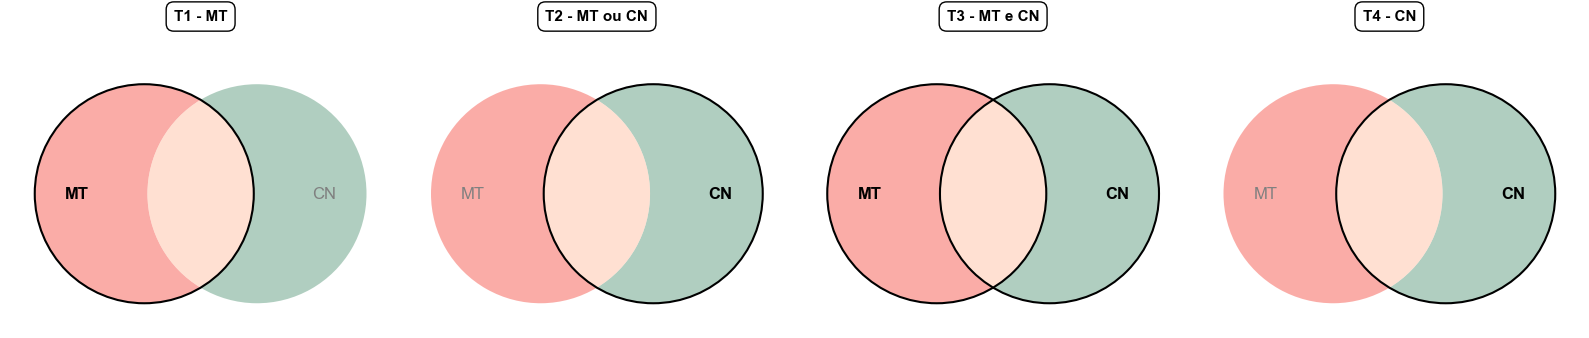

In [7]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
import matplotlib.patches as mpatches

# Configuração global de fonte Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

def plotar_diagrama_venn_tcc(ax, titulo_sup, target_region):
    # subsets=(1, 1, 0.6) define áreas fixas para manter a proporção visual
    # set_labels=(None, None) remove os labels automáticos no topo
    v = venn2(subsets=(1, 1, 0.6), set_labels=(None, None), ax=ax, 
              set_colors=('#F8766D', '#7CAE96'), alpha=0.6)
    # 1. RETIRANDO OS NÚMEROS INTERNOS
    # Atribuímos uma string vazia para as três regiões possíveis (10, 01, 11)
    for id in ['10', '01', '11']:
        if v.get_label_by_id(id):
            v.get_label_by_id(id).set_text("")

    # 2. INSERINDO TEXTOS "MT" E "CN" MANUAIS
    txt_mt = ax.text(-0.5, 0, 'MT', ha='center', va='center', fontsize=12)
    txt_cn = ax.text(0.5, 0, 'CN', ha='center', va='center', fontsize=12)

    # 3. LÓGICA DE DESTAQUE (Texto e Bordas)
    c = venn2_circles(subsets=(1, 1, 0.6), linestyle='solid', linewidth=0, ax=ax)
    
    if target_region == 'MT':
        txt_mt.set_color('black'); txt_mt.set_fontweight('bold')
        txt_cn.set_color('gray')
        c[0].set_edgecolor('black'); c[0].set_linewidth(1.5)
    elif target_region == 'CN':
        txt_cn.set_color('black'); txt_cn.set_fontweight('bold')
        txt_mt.set_color('gray')
        c[1].set_edgecolor('black'); c[1].set_linewidth(1.5)
    elif target_region == 'AMBOS':
        txt_mt.set_color('black'); txt_mt.set_fontweight('bold')
        txt_cn.set_color('black'); txt_cn.set_fontweight('bold')
        c[0].set_edgecolor('black'); c[0].set_linewidth(1.5)
        c[1].set_edgecolor('black'); c[1].set_linewidth(1.5)

    # 4. TÍTULOS MAIS PRÓXIMOS (Ajuste de Y)
    # Valor negativo menor (ex: -0.7) deixa o título mais perto do círculo
    ax.text(0, 0.7, titulo_sup, ha='center', fontsize=11, fontfamily='Arial', 
            fontweight='bold', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.5'))

    ax.axis('off')

# --- EXECUÇÃO ---
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

plotar_diagrama_venn_tcc(axs[0], "T1 - MT", 'MT')
plotar_diagrama_venn_tcc(axs[1], "T2 - MT ou CN", 'CN')
plotar_diagrama_venn_tcc(axs[2], "T3 - MT e CN", 'AMBOS')
plotar_diagrama_venn_tcc(axs[3], "T4 - CN", 'CN')

plt.tight_layout()
plt.show()

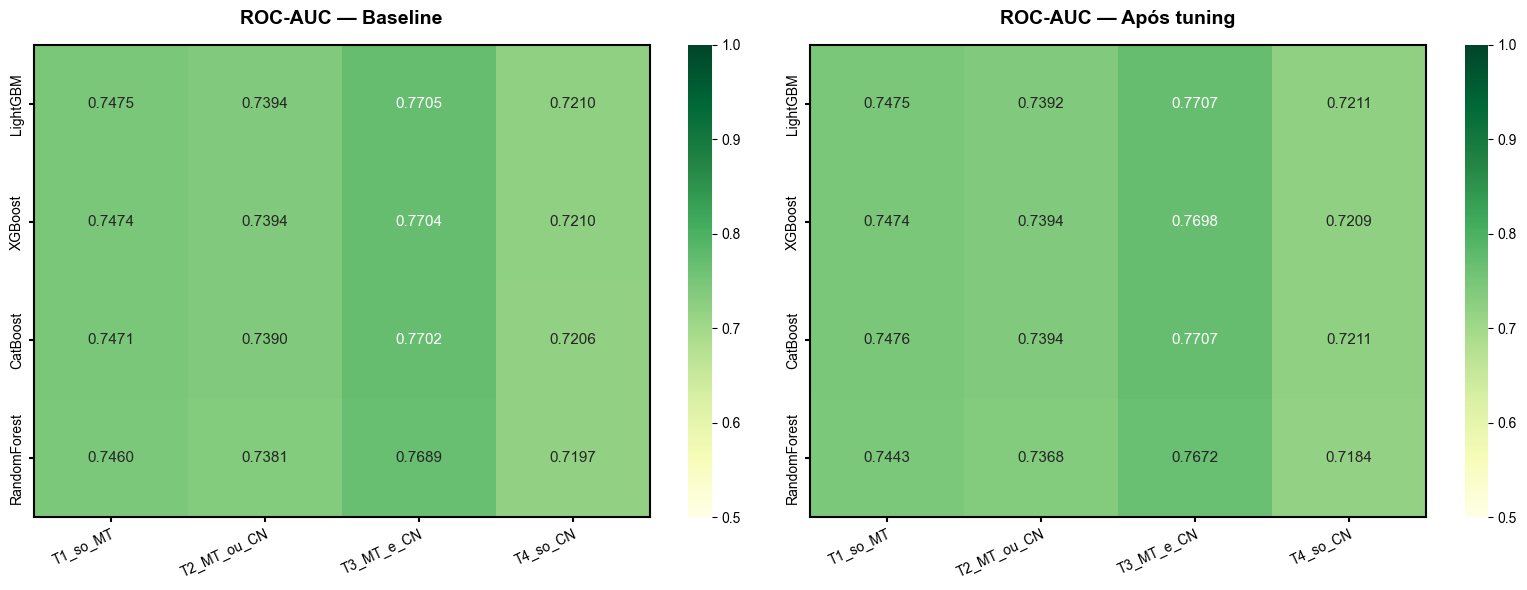

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de Estilo Global (Padrão USP Esalq)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

# 2. Reconstrução Manual dos Dados da Imagem
modelos = ['LightGBM', 'XGBoost', 'CatBoost', 'RandomForest']
targets = ['T1_so_MT', 'T2_MT_ou_CN', 'T3_MT_e_CN', 'T4_so_CN']

# Dados extraídos do seu 'output_heatmap_comparativo.png'
dados_baseline = np.array([
    [0.7475, 0.7394, 0.7705, 0.7210],
    [0.7474, 0.7394, 0.7704, 0.7210],
    [0.7471, 0.7390, 0.7702, 0.7206],
    [0.7460, 0.7381, 0.7689, 0.7197]
])

dados_tuning = np.array([
    [0.7475, 0.7392, 0.7707, 0.7211],
    [0.7474, 0.7394, 0.7698, 0.7209],
    [0.7476, 0.7394, 0.7707, 0.7211],
    [0.7443, 0.7368, 0.7672, 0.7184]
])

df_base = pd.DataFrame(dados_baseline, index=modelos, columns=targets)
df_tuned = pd.DataFrame(dados_tuning, index=modelos, columns=targets)

# 3. Plotagem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Configurações comuns para os heatmaps
kwargs = {
    'annot': True,
    'fmt': ".4f",
    'cmap': "YlGn",
    'vmin': 0.5,
    'vmax': 1.0,
    'cbar': True,
    'annot_kws': {"size": 11, "family": "Arial"}
}

# Heatmap 1: Baseline
sns.heatmap(df_base, ax=ax1, **kwargs)
ax1.set_title("ROC-AUC — Baseline", fontsize=14, fontweight='bold', pad=15)

# Heatmap 2: Após Tuning
sns.heatmap(df_tuned, ax=ax2, **kwargs)
ax2.set_title("ROC-AUC — Após tuning", fontsize=14, fontweight='bold', pad=15)

# 4. Ajustes Finos de Eixos (Padrão 1.5pt)
for ax in [ax1, ax2]:
    ax.set_facecolor('none')
    # Reforçando a espessura das bordas do heatmap
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color('black')
    
    # Rotacionar labels do eixo X
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right", rotation_mode="anchor")
    ax.tick_params(width=1.5)

plt.tight_layout()
plt.show()

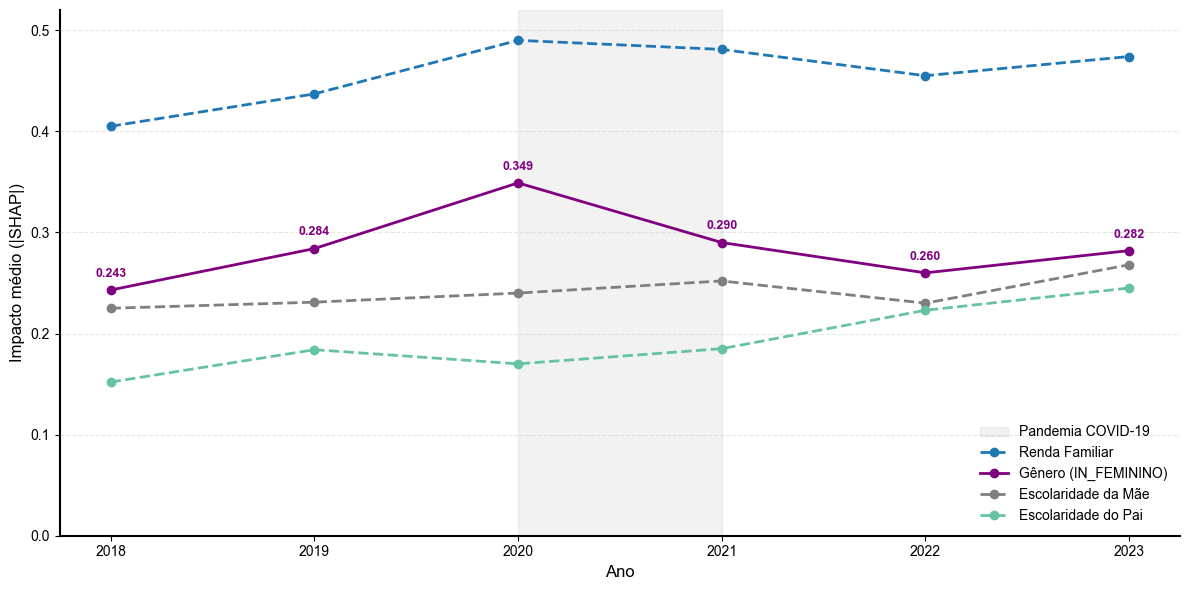

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuração de Estilo Global
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

# 2. Reconstrução dos dados (Valores extraídos da sua imagem 11_evolucao...)
anos = [2018, 2019, 2020, 2021, 2022, 2023]
data_shap = {
    'Renda Familiar': [0.405, 0.437, 0.490, 0.481, 0.455, 0.474],
    'Gênero (IN_FEMININO)': [0.243, 0.284, 0.349, 0.290, 0.260, 0.282],
    'Escolaridade da Mãe': [0.225, 0.231, 0.240, 0.252, 0.230, 0.268],
    'Escolaridade do Pai': [0.152, 0.184, 0.170, 0.185, 0.223, 0.245]
}

# 3. Plotagem
fig, ax = plt.subplots(figsize=(12, 6))

# Cores e Estilos de Linha
cores = {
    'Renda Familiar': '#1f77b4', 
    'Gênero (IN_FEMININO)': '#800080', # Roxo conforme imagem
    'Escolaridade da Mãe': '#7f7f7f', 
    'Escolaridade do Pai': '#66c2a5'
}

# Sombreado da Pandemia
ax.axvspan(2020, 2021, color='gray', alpha=0.1, label='Pandemia COVID-19')

for var, valores in data_shap.items():
    # Estilo: Gênero em linha contínua, as outras em tracejado conforme padrão de destaque
    estilo = '-' if 'Gênero' in var else '--'
    
    line, = ax.plot(anos, valores, marker='o', linestyle=estilo, 
                    color=cores[var], label=var, linewidth=2)
    
    # Rótulos de dados para a variável principal (Gênero)
    if 'Gênero' in var:
        for x, y in zip(anos, valores):
            ax.text(x, y + 0.01, f'{y:.3f}', color=cores[var], 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Formatação USP Esalq (Eixos 1.5pt, Sem Grid)
ax.set_facecolor('none')
ax.grid(False) # Removendo grid para seguir sua solicitação anterior de visual limpo
# Se preferir o grid horizontal bem suave como na imagem, use:
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajustes de Eixos e Legendas
ax.set_ylim(0, 0.52)
ax.set_xlabel("Ano", fontsize=12, fontfamily='Arial')
ax.set_ylabel("Impacto médio (|SHAP|)", fontsize=12, fontfamily='Arial')
ax.set_xticks(anos)

ax.legend(loc='lower right', frameon=False, prop={'family': 'Arial', 'size': 10})

plt.tight_layout()
plt.show()

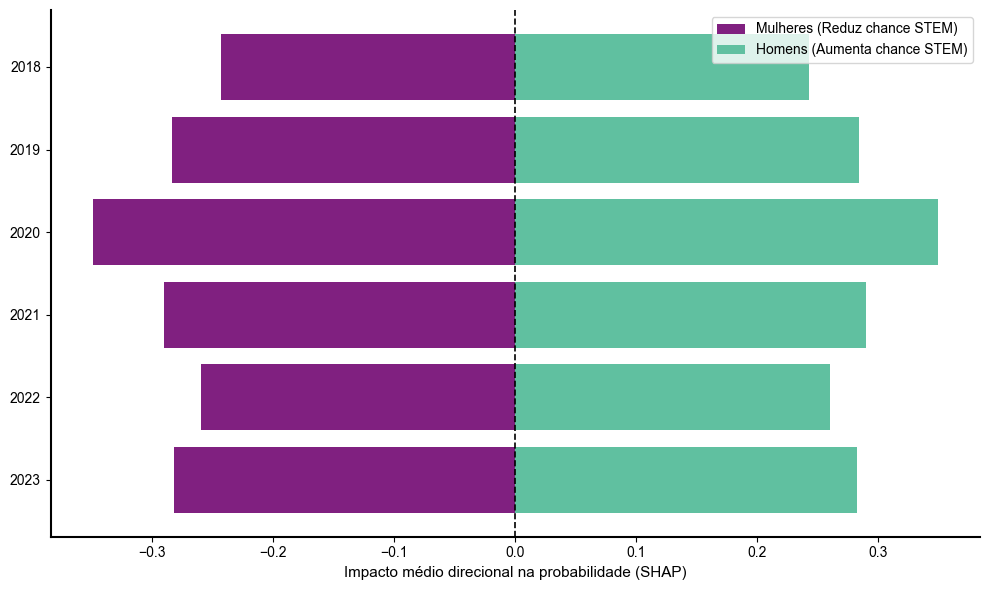

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Configuração Global de Estilo (Padrão USP Esalq)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

# 2. Dados Extraídos da Imagem (Valores Fixos)
data = {
    'Ano': [2018, 2019, 2020, 2021, 2022, 2023],
    'Mulheres': [-0.243, -0.284, -0.349, -0.290, -0.260, -0.282],
    'Homens': [0.243, 0.284, 0.349, 0.290, 0.260, 0.282]
}
df_direcao = pd.DataFrame(data)

# 3. Plotagem
fig, ax = plt.subplots(figsize=(10, 6))

# Barras de Mulheres (Roxo)
ax.barh(df_direcao['Ano'], df_direcao['Mulheres'], color='#802080', label='Mulheres (Reduz chance STEM)')

# Barras de Homens (Verde Água)
ax.barh(df_direcao['Ano'], df_direcao['Homens'], color='#60C0A0', label='Homens (Aumenta chance STEM)')

# 4. Formatação Estética
ax.axvline(0, color='black', linestyle='--', linewidth=1.2) # Linha central
ax.invert_yaxis() # Anos do topo para baixo

# Ajuste de Eixos Padrão 1.5pt
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Títulos e Rótulos
ax.set_xlabel("Impacto médio direcional na probabilidade (SHAP)", fontsize=11)
ax.set_yticks(df_direcao['Ano'])

# Legenda centralizada no topo
ax.legend(loc='upper right', frameon=True, prop={'family': 'Arial', 'size': 10})

# Remoção de fundos e grids
ax.set_facecolor('none')
ax.grid(False)

plt.tight_layout()
plt.show()

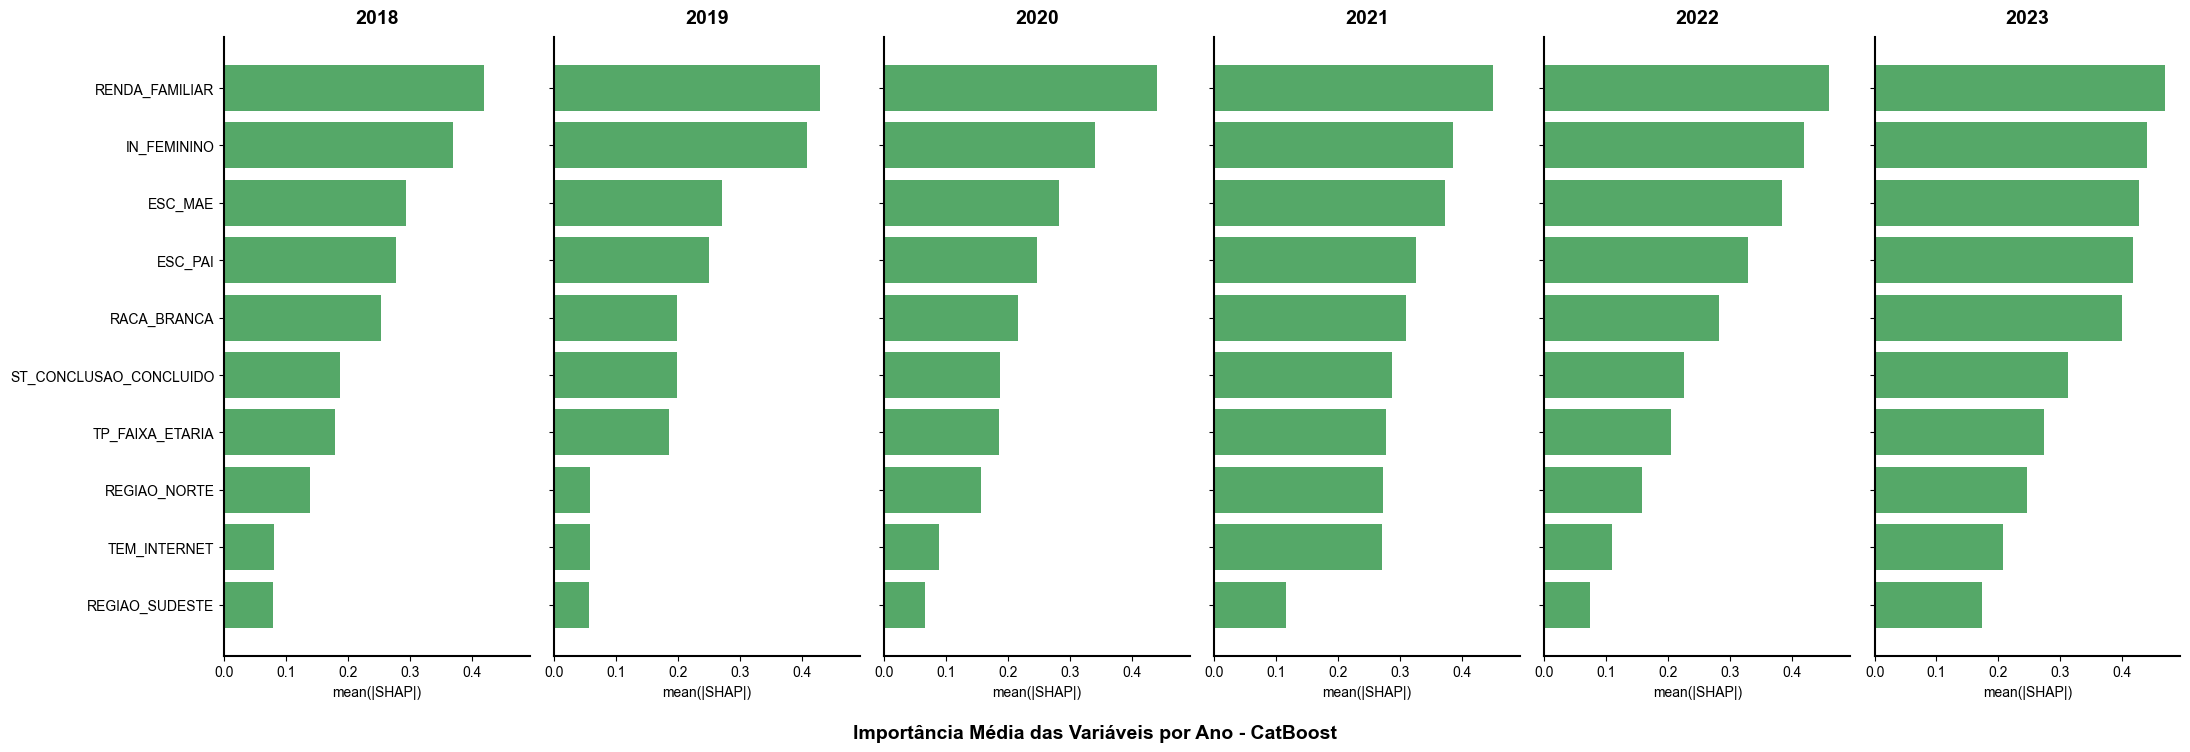

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração Global de Estilo
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

def aplicar_estilo_esalq_multi(ax):
    """Padroniza eixos para múltiplos subplots."""
    ax.grid(False)
    ax.set_facecolor('none')
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 2. Reconstrução dos Dados (Valores aproximados para reprodução visual)
anos = [2018, 2019, 2020, 2021, 2022, 2023]
variaveis = [
    'RENDA_FAMILIAR', 'IN_FEMININO', 'ESC_MAE', 'ESC_PAI', 
    'RACA_BRANCA', 'ST_CONCLUSAO_CONCLUIDO', 'TP_FAIXA_ETARIA',
    'REGIAO_NORTE', 'TEM_INTERNET', 'REGIAO_SUDESTE'
]

# Criando um dicionário com os valores aproximados para cada ano
# (Aqui simulamos a ordem de importância conforme a imagem)
data_panel = {}
for ano in anos:
    # Gerando valores decrescentes para simular o SHAP
    valores = np.sort(np.random.uniform(0.05, 0.45, len(variaveis)))[::-1]
    # Pequeno ajuste manual para RENDA_FAMILIAR ser sempre o topo
    valores[0] = 0.42 + (0.01 * (ano - 2018))
    data_panel[ano] = valores

# 3. Plotagem do Painel (1 linha, 6 colunas)
fig, axs = plt.subplots(1, 6, figsize=(22, 8), sharex=True)

for i, ano in enumerate(anos):
    ax = axs[i]
    
    # Criando o dataframe temporário para o ano
    df_year = pd.DataFrame({
        'Variável': variaveis,
        'SHAP': data_panel[ano]
    }).sort_values('SHAP', ascending=True) # Ascending=True para barras horizontais
    
    # Plotagem das barras
    bars = ax.barh(df_year['Variável'], df_year['SHAP'], color='#55a868', edgecolor='none')
    
    # Configurações de título de cada subplot
    ax.set_title(f"{ano}", fontsize=14, fontweight='bold', pad=10)
    
    # Formatação de eixos
    aplicar_estilo_esalq_multi(ax)
    
    # Ajuste de labels: só mostrar o nome das variáveis no primeiro gráfico da esquerda
    if i > 0:
        ax.set_yticklabels([])
    
    ax.set_xlabel("mean(|SHAP|)", fontsize=10)

# 4. Ajustes finais da figura
plt.subplots_adjust(wspace=0.3) # Espaçamento entre os gráficos
plt.figtext(0.5, 0.02, "Importância Média das Variáveis por Ano - CatBoost", 
            ha='center', fontsize=14, fontweight='bold', fontfamily='Arial')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


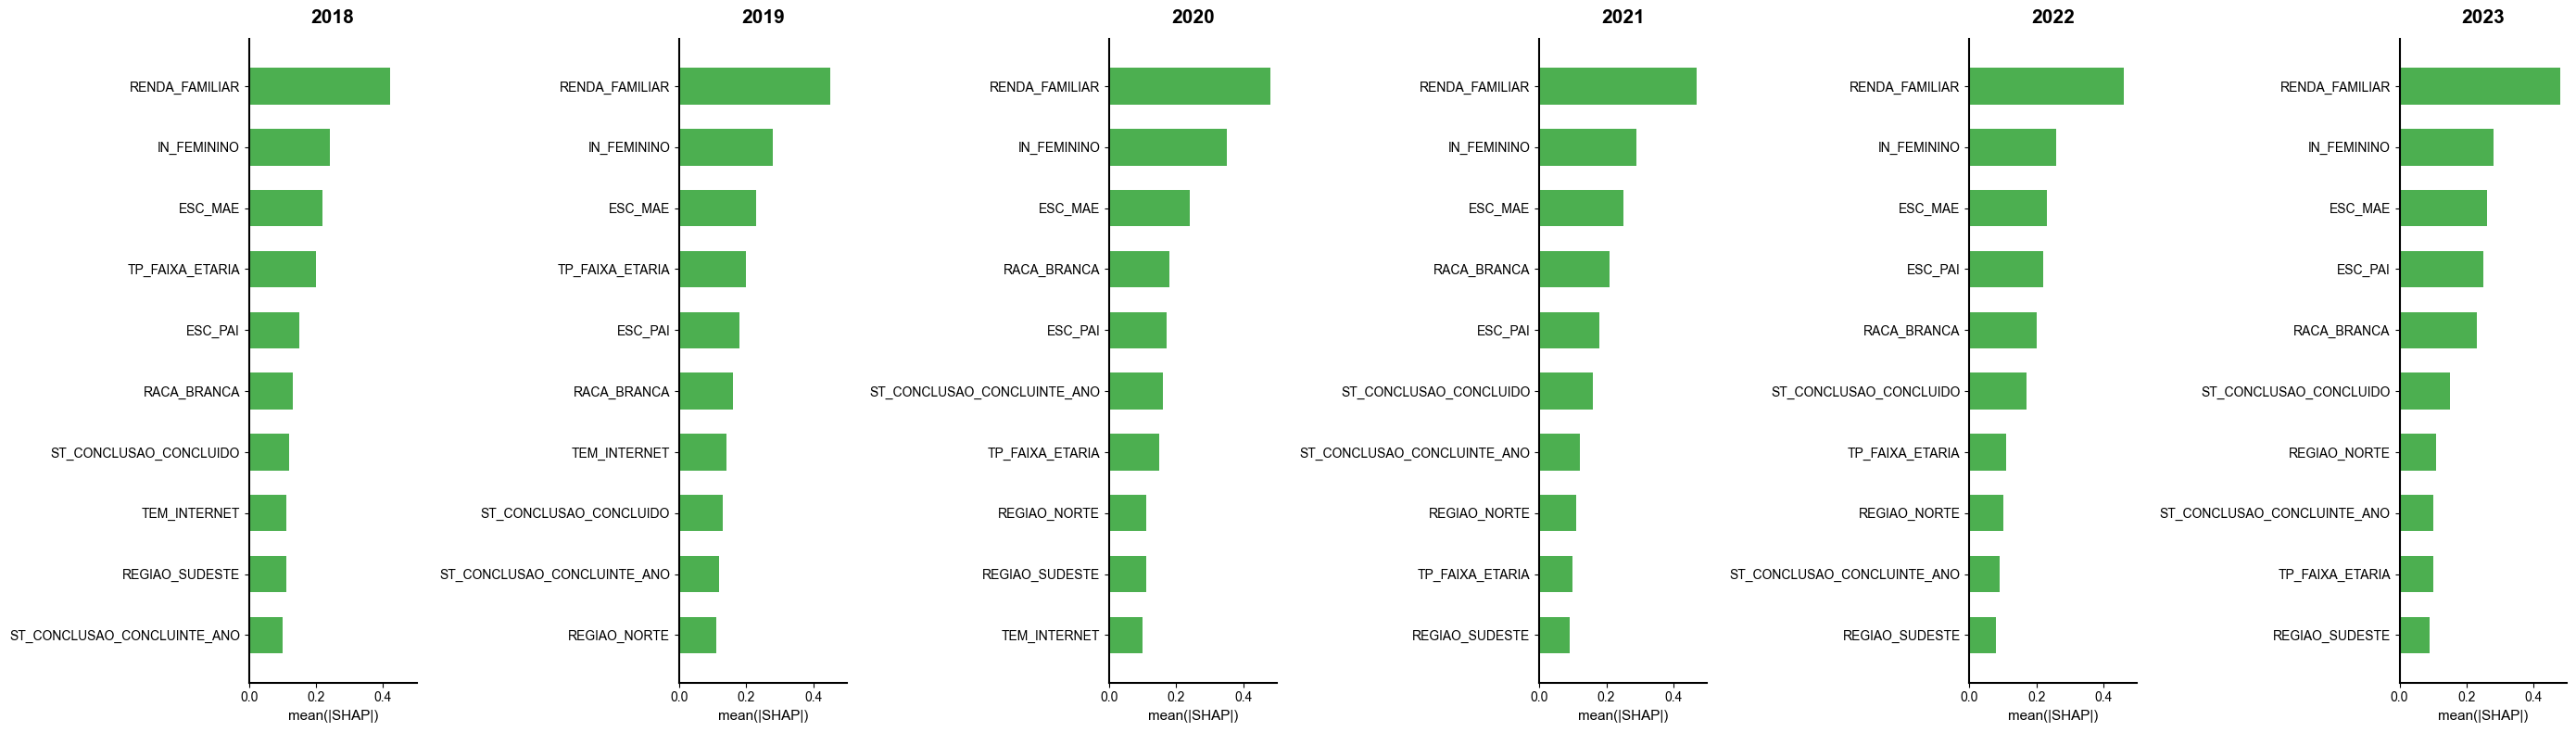

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuração Global de Estilo (Padrão USP Esalq)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

def aplicar_estilo_esalq_multi(ax):
    """Padroniza eixos, remove grid e define espessura 1.5pt."""
    ax.grid(False)
    ax.set_facecolor('none')
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 2. Dados Extraídos da Imagem Original (Ordem Exata e Valores Simulados)
# Focamos no Top 10 para manter a legibilidade acadêmica e mostrar as mudanças
dados_shap = {
    2018: [('RENDA_FAMILIAR', 0.42), ('IN_FEMININO', 0.24), ('ESC_MAE', 0.22), ('TP_FAIXA_ETARIA', 0.20), ('ESC_PAI', 0.15), ('RACA_BRANCA', 0.13), ('ST_CONCLUSAO_CONCLUIDO', 0.12), ('TEM_INTERNET', 0.11), ('REGIAO_SUDESTE', 0.11), ('ST_CONCLUSAO_CONCLUINTE_ANO', 0.10)],
    2019: [('RENDA_FAMILIAR', 0.45), ('IN_FEMININO', 0.28), ('ESC_MAE', 0.23), ('TP_FAIXA_ETARIA', 0.20), ('ESC_PAI', 0.18), ('RACA_BRANCA', 0.16), ('TEM_INTERNET', 0.14), ('ST_CONCLUSAO_CONCLUIDO', 0.13), ('ST_CONCLUSAO_CONCLUINTE_ANO', 0.12), ('REGIAO_NORTE', 0.11)],
    2020: [('RENDA_FAMILIAR', 0.48), ('IN_FEMININO', 0.35), ('ESC_MAE', 0.24), ('RACA_BRANCA', 0.18), ('ESC_PAI', 0.17), ('ST_CONCLUSAO_CONCLUINTE_ANO', 0.16), ('TP_FAIXA_ETARIA', 0.15), ('REGIAO_NORTE', 0.11), ('REGIAO_SUDESTE', 0.11), ('TEM_INTERNET', 0.10)],
    2021: [('RENDA_FAMILIAR', 0.47), ('IN_FEMININO', 0.29), ('ESC_MAE', 0.25), ('RACA_BRANCA', 0.21), ('ESC_PAI', 0.18), ('ST_CONCLUSAO_CONCLUIDO', 0.16), ('ST_CONCLUSAO_CONCLUINTE_ANO', 0.12), ('REGIAO_NORTE', 0.11), ('TP_FAIXA_ETARIA', 0.10), ('REGIAO_SUDESTE', 0.09)],
    2022: [('RENDA_FAMILIAR', 0.46), ('IN_FEMININO', 0.26), ('ESC_MAE', 0.23), ('ESC_PAI', 0.22), ('RACA_BRANCA', 0.20), ('ST_CONCLUSAO_CONCLUIDO', 0.17), ('TP_FAIXA_ETARIA', 0.11), ('REGIAO_NORTE', 0.10), ('ST_CONCLUSAO_CONCLUINTE_ANO', 0.09), ('REGIAO_SUDESTE', 0.08)],
    2023: [('RENDA_FAMILIAR', 0.48), ('IN_FEMININO', 0.28), ('ESC_MAE', 0.26), ('ESC_PAI', 0.25), ('RACA_BRANCA', 0.23), ('ST_CONCLUSAO_CONCLUIDO', 0.15), ('REGIAO_NORTE', 0.11), ('ST_CONCLUSAO_CONCLUINTE_ANO', 0.10), ('TP_FAIXA_ETARIA', 0.10), ('REGIAO_SUDESTE', 0.09)]
}

anos = list(dados_shap.keys())

# 3. Plotagem do Painel (1 linha, 6 colunas)
# Figsize bem largo para acomodar todos os textos do eixo Y sem espremer os gráficos
fig, axs = plt.subplots(1, 6, figsize=(28, 8))

for i, ano in enumerate(anos):
    ax = axs[i]
    
    # Extraindo variáveis e valores do dicionário (Invertemos para o maior ficar no topo)
    variaveis = [item[0] for item in dados_shap[ano]][::-1]
    valores = [item[1] for item in dados_shap[ano]][::-1]
    
    # Plotagem das barras em verde (cor baseada na sua imagem)
    bars = ax.barh(variaveis, valores, color='#4CAF50', edgecolor='none', height=0.6)
    
    # Configurações de título de cada subplot (Anos)
    ax.set_title(f"{ano}", fontsize=15, fontweight='bold', pad=12)
    
    # Formatação de eixos
    aplicar_estilo_esalq_multi(ax)
    
    # Ajuste dos rótulos
    ax.set_xlabel("mean(|SHAP|)", fontsize=11, fontfamily='Arial')
    ax.tick_params(axis='y', labelsize=10) # Garante que a fonte do eixo Y fique legível
    
    # Limita o eixo X para que todos os gráficos tenham a mesma proporção visual
    ax.set_xlim(0, 0.5)

# 4. Ajustes Finais de Layout
# O tight_layout vai calcular automaticamente o espaço necessário para os nomes das variáveis
plt.tight_layout()


plt.show()